# Análise e Modelagem do Preço do Petróleo Brent

## FIAP — Tech Challenge — Fase 04

Este notebook apresenta o desenvolvimento de um MVP para análise e previsão do preço do petróleo Brent.

O projeto contempla:

- carregamento e tratamento dos dados;
- análise exploratória;
- criação de baseline;
- engenharia de features temporais;
- treinamento de modelo preditivo;
- comparação entre modelo e baseline;
- conclusão sobre os resultados obtidos.

In [2]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PROCESSED = ROOT / "data" / "processed"
REPORTS = ROOT / "reports"
MODELS = ROOT / "models"

CAMINHO_DADOS_TRATADOS = DATA_PROCESSED / "petroleo_brent_tratado.csv"
CAMINHO_DADOS_FEATURES = DATA_PROCESSED / "petroleo_brent_features.csv"

CAMINHO_BASELINE_METRICAS = REPORTS / "baseline_metricas.json"
CAMINHO_MODELO_METRICAS = REPORTS / "metricas_modelo.json"
CAMINHO_PREVISOES_MODELO = REPORTS / "previsoes_modelo.csv"

CAMINHO_MODELO = MODELS / "modelo_petroleo.joblib"

print("Raiz do projeto:", ROOT)
print("Base tratada existe?", CAMINHO_DADOS_TRATADOS.exists())
print("Base com features existe?", CAMINHO_DADOS_FEATURES.exists())
print("Métricas do baseline existem?", CAMINHO_BASELINE_METRICAS.exists())
print("Métricas do modelo existem?", CAMINHO_MODELO_METRICAS.exists())
print("Previsões do modelo existem?", CAMINHO_PREVISOES_MODELO.exists())
print("Modelo salvo existe?", CAMINHO_MODELO.exists())

Raiz do projeto: c:\Users\ninja\Dropbox\FIAP\Pós-Tech - Data Analytics\fase_04\fiap-fase04-oil-forecast
Base tratada existe? True
Base com features existe? True
Métricas do baseline existem? True
Métricas do modelo existem? True
Previsões do modelo existem? True
Modelo salvo existe? True


# 1. Carregamento dos dados

Nesta etapa, são carregados os arquivos gerados nos tijolos anteriores:

- base tratada;
- base com features temporais;
- métricas do baseline;
- métricas do modelo;
- previsões do modelo.

In [4]:
df_tratado = pd.read_csv(CAMINHO_DADOS_TRATADOS, parse_dates=["data"])
df_features = pd.read_csv(CAMINHO_DADOS_FEATURES, parse_dates=["data"])
df_previsoes = pd.read_csv(CAMINHO_PREVISOES_MODELO, parse_dates=["data"])

with open(CAMINHO_BASELINE_METRICAS, "r", encoding="utf-8") as arquivo:
    metricas_baseline = json.load(arquivo)

with open(CAMINHO_MODELO_METRICAS, "r", encoding="utf-8") as arquivo:
    metricas_modelo = json.load(arquivo)

print("Base tratada:", df_tratado.shape)
print("Base com features:", df_features.shape)
print("Previsões do modelo:", df_previsoes.shape)

Base tratada: (11706, 2)
Base com features: (11676, 12)
Previsões do modelo: (2336, 6)


# 2. Visão geral da base tratada

A base tratada contém a data e o preço diário do petróleo Brent em dólares.

In [5]:
df_tratado.head()

resumo_base = pd.DataFrame({
    "indicador": [
        "quantidade_linhas",
        "data_inicial",
        "data_final",
        "preco_minimo",
        "preco_maximo",
        "preco_medio",
        "preco_mediano",
        "valores_ausentes",
    ],
    "valor": [
        len(df_tratado),
        df_tratado["data"].min().date(),
        df_tratado["data"].max().date(),
        round(df_tratado["preco_usd"].min(), 2),
        round(df_tratado["preco_usd"].max(), 2),
        round(df_tratado["preco_usd"].mean(), 2),
        round(df_tratado["preco_usd"].median(), 2),
        int(df_tratado.isna().sum().sum()),
    ],
})

resumo_base

,indicador,valor
0,quantidade_linhas,11706
1,data_inicial,1987-05-20
2,data_final,2026-06-29
3,preco_minimo,9.1
4,preco_maximo,143.95
5,preco_medio,54.12
6,preco_mediano,51.21
7,valores_ausentes,0


# 3. Análise exploratória

O gráfico abaixo apresenta a evolução histórica do preço do petróleo Brent.

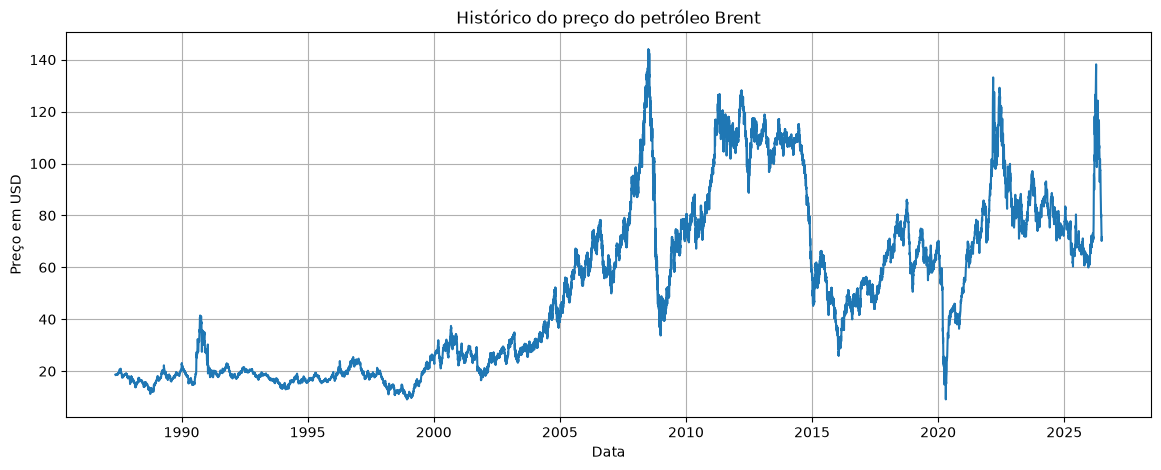

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df_tratado["data"], df_tratado["preco_usd"])
plt.title("Histórico do preço do petróleo Brent")
plt.xlabel("Data")
plt.ylabel("Preço em USD")
plt.grid(True)
plt.show()

In [8]:
df_tratado["preco_usd"].describe()

count    11706.000000
mean        54.124583
std         32.980114
min          9.100000
25%         21.080000
50%         51.210000
75%         76.850000
max        143.950000
Name: preco_usd, dtype: float64

# 4. Baseline

O baseline é uma regra simples usada como referência para avaliar o modelo.

Neste projeto, o baseline adotado foi:

> preço previsto de hoje = preço de ontem

Esse baseline é importante porque permite verificar se o modelo de machine learning realmente agrega valor em relação a uma estratégia simples.

In [9]:
pd.DataFrame([metricas_baseline])

,modelo,mae,rmse,mape,quantidade_linhas_avaliadas,primeira_linha_avaliada,ultima_linha_avaliada
0,Baseline - preço previsto de hoje igual ao pre...,0.9375,1.5177,1.7901,11705,1987-05-21,2026-06-29


# 5. Features temporais

Foram criadas variáveis temporais a partir do histórico do preço do petróleo Brent.

As principais features utilizadas foram:

- preço do dia anterior;
- preço de 7 dias anteriores;
- preço de 30 dias anteriores;
- média móvel de 7 dias;
- média móvel de 30 dias;
- variação de 1 dia;
- variação de 7 dias;
- ano;
- mês;
- dia da semana.

As features foram construídas usando apenas informações disponíveis até o dia anterior, evitando vazamento de dados futuros.

In [10]:
df_features.head()

,data,preco_usd,lag_1,lag_7,lag_30,media_7,media_30,variacao_1,variacao_7,ano,mes,dia_da_semana
0,1987-07-02,19.25,18.98,18.90,18.63,18.948571,18.789667,-0.10,0.08,1987,7,3
1,1987-07-03,19.33,19.25,18.75,18.45,18.998571,18.810333,0.27,0.50,1987,7,4
2,1987-07-06,19.48,19.33,18.70,18.55,19.081429,18.839667,0.08,0.63,1987,7,0
3,1987-07-07,19.50,19.48,19.08,18.60,19.192857,18.870667,0.15,0.40,1987,7,1
4,1987-07-08,19.48,19.50,19.15,18.63,19.252857,18.900667,0.02,0.35,1987,7,2


In [11]:
df_features.columns.tolist()

['data',
 'preco_usd',
 'lag_1',
 'lag_7',
 'lag_30',
 'media_7',
 'media_30',
 'variacao_1',
 'variacao_7',
 'ano',
 'mes',
 'dia_da_semana']

# 6. Modelo preditivo

Foi treinado um modelo Random Forest Regressor usando as features temporais.

A separação entre treino e teste respeitou a ordem temporal da série:

- primeiros 80% dos dados para treino;
- últimos 20% dos dados para teste.

Essa abordagem evita embaralhar os dados no tempo e simula melhor um cenário real de previsão.

In [12]:
resumo_modelo = pd.DataFrame({
    "item": [
        "modelo",
        "linhas_treino",
        "linhas_teste",
        "primeira_data_treino",
        "ultima_data_treino",
        "primeira_data_teste",
        "ultima_data_teste",
        "mae",
        "rmse",
        "mape",
    ],
    "valor": [
        metricas_modelo["modelo"],
        metricas_modelo["quantidade_linhas_treino"],
        metricas_modelo["quantidade_linhas_teste"],
        metricas_modelo["primeira_data_treino"],
        metricas_modelo["ultima_data_treino"],
        metricas_modelo["primeira_data_teste"],
        metricas_modelo["ultima_data_teste"],
        metricas_modelo["mae"],
        metricas_modelo["rmse"],
        metricas_modelo["mape"],
    ],
})

resumo_modelo

,item,valor
0,modelo,RandomForestRegressor
1,linhas_treino,9340
2,linhas_teste,2336
3,primeira_data_treino,1987-07-02
4,ultima_data_treino,2017-09-10
5,primeira_data_teste,2017-09-11
6,ultima_data_teste,2026-06-29
7,mae,1.4801
8,rmse,2.1828
9,mape,2.1345


# 7. Comparação entre modelo e baseline

A comparação correta deve ser feita no mesmo período de teste.

Por isso, além do baseline geral, foi calculado o baseline no mesmo intervalo usado para avaliar o modelo.

In [13]:
comparacao_baseline = metricas_modelo["comparacao_baseline"]

df_comparacao = pd.DataFrame({
    "metrica": ["MAE", "RMSE", "MAPE"],
    "modelo_random_forest": [
        metricas_modelo["mae"],
        metricas_modelo["rmse"],
        metricas_modelo["mape"],
    ],
    "baseline_teste": [
        comparacao_baseline["mae_baseline_teste"],
        comparacao_baseline["rmse_baseline_teste"],
        comparacao_baseline["mape_baseline_teste"],
    ],
    "modelo_melhor_que_baseline": [
        comparacao_baseline["modelo_melhor_que_baseline_mae"],
        comparacao_baseline["modelo_melhor_que_baseline_rmse"],
        comparacao_baseline["modelo_melhor_que_baseline_mape"],
    ],
})

df_comparacao

,metrica,modelo_random_forest,baseline_teste,modelo_melhor_que_baseline
0,MAE,1.4801,1.2732,False
1,RMSE,2.1828,1.9691,False
2,MAPE,2.1345,1.8398,False


# 8. Visualização das previsões

O gráfico abaixo compara o preço real com o preço previsto pelo modelo no final do período de teste.

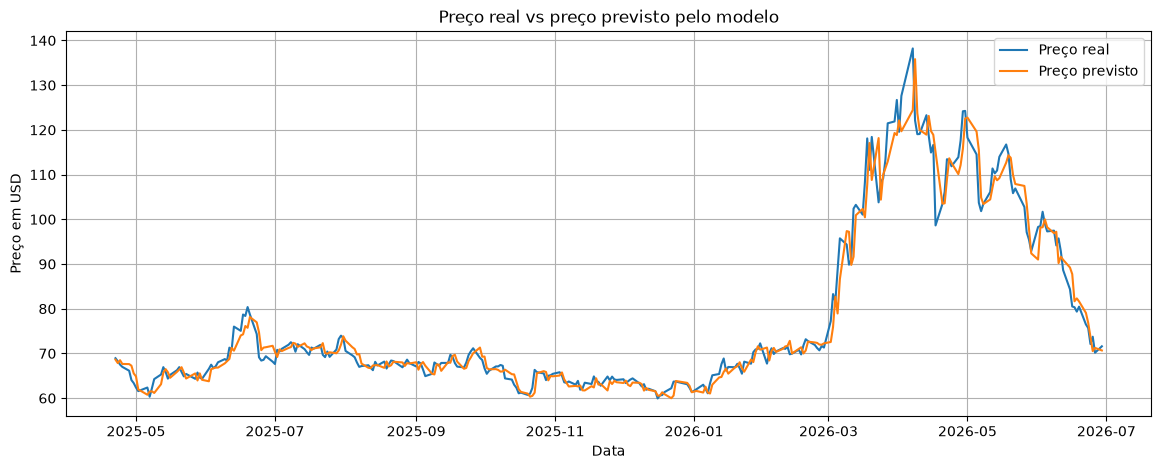

In [15]:
amostra = df_previsoes.tail(300)

plt.figure(figsize=(14, 5))
plt.plot(amostra["data"], amostra["preco_real"], label="Preço real")
plt.plot(amostra["data"], amostra["preco_previsto"], label="Preço previsto")
plt.title("Preço real vs preço previsto pelo modelo")
plt.xlabel("Data")
plt.ylabel("Preço em USD")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
df_previsoes.tail(10)

,data,preco_real,preco_previsto,erro,erro_absoluto,erro_percentual_absoluto
2326,2026-06-16,80.50,87.74310,-7.24310,7.24310,8.997640
2327,2026-06-17,80.33,81.65895,-1.32895,1.32895,1.654363
2328,2026-06-18,79.35,82.30830,-2.95830,2.95830,3.728166
2329,2026-06-19,80.46,81.62535,-1.16535,1.16535,1.448359
2330,2026-06-22,76.49,79.07355,-2.58355,2.58355,3.377631
2331,2026-06-23,75.69,76.86355,-1.17355,1.17355,1.550469
2332,2026-06-24,72.09,73.63675,-1.54675,1.54675,2.145582
2333,2026-06-25,73.74,70.51840,3.22160,3.22160,4.368864
2334,2026-06-26,70.16,71.23800,-1.07800,1.07800,1.536488
2335,2026-06-29,71.59,70.66335,0.92665,0.92665,1.294385


# 9. Análise dos erros

Abaixo analisamos a distribuição dos erros e os maiores erros absolutos do modelo.

In [17]:
df_previsoes["erro_absoluto"].describe()

count    2336.000000
mean        1.480081
std         1.604671
min         0.001100
25%         0.468387
50%         1.043450
75%         1.973063
max        16.459600
Name: erro_absoluto, dtype: float64

In [18]:
df_previsoes.sort_values('erro_absoluto', ascending=False).head(10)

,data,preco_real,preco_previsto,erro,erro_absoluto,erro_percentual_absoluto
2286,2026-04-17,98.63,115.08960,-16.45960,16.45960,16.688229
1247,2022-03-09,116.58,132.82765,-16.24765,16.24765,13.936910
2269,2026-03-23,103.79,118.16095,-14.37095,14.37095,13.846180
736,2020-03-09,35.33,49.62140,-14.29140,14.29140,40.451175
2278,2026-04-07,138.21,124.42000,13.79000,13.79000,9.977570
2279,2026-04-08,122.11,135.81550,-13.70550,13.70550,11.223896
2298,2026-05-06,103.70,115.47400,-11.77400,11.77400,11.353905
2262,2026-03-12,102.38,91.61860,10.76140,10.76140,10.511233
1175,2021-11-26,72.37,83.08825,-10.71825,10.71825,14.810350
2266,2026-03-18,118.09,107.69090,10.39910,10.39910,8.806080


# 10. Conclusão

O modelo Random Forest foi treinado com sucesso usando features temporais derivadas do histórico do preço do petróleo Brent.

No entanto, ao comparar o modelo com o baseline no mesmo período de teste, o baseline apresentou desempenho melhor nas três métricas avaliadas: MAE, RMSE e MAPE.

Isso indica que, para previsão diária do preço do Brent, repetir o preço do dia anterior é uma referência bastante forte.

O resultado reforça a importância de sempre utilizar um baseline em projetos de machine learning, pois um modelo mais complexo nem sempre supera uma regra simples.

Como próximos passos, o projeto pode evoluir com:

- teste de outros modelos;
- criação de novas features;
- inclusão de variáveis externas;
- previsão em horizontes maiores;
- disponibilização do modelo em uma aplicação Streamlit.